In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

## Load data and drop non-predictive columns

- `customerID`: pure identifier, no predictive value.
- `gender`, `PaperlessBilling`: dropped here per initial decision — **TODO: revisit after EDA** to confirm these truly have no relationship with churn before finalizing. Dropping features should be justified by evidence, not assumption.

In [3]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.drop(columns=["customerID", "gender", "PaperlessBilling"], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SeniorCitizen     7043 non-null   int64  
 1   Partner           7043 non-null   object 
 2   Dependents        7043 non-null   object 
 3   tenure            7043 non-null   int64  
 4   PhoneService      7043 non-null   object 
 5   MultipleLines     7043 non-null   object 
 6   InternetService   7043 non-null   object 
 7   OnlineSecurity    7043 non-null   object 
 8   OnlineBackup      7043 non-null   object 
 9   DeviceProtection  7043 non-null   object 
 10  TechSupport       7043 non-null   object 
 11  StreamingTV       7043 non-null   object 
 12  StreamingMovies   7043 non-null   object 
 13  Contract          7043 non-null   object 
 14  PaymentMethod     7043 non-null   object 
 15  MonthlyCharges    7043 non-null   float64
 16  TotalCharges      7043 non-null   object 


## Fix `TotalCharges`

`TotalCharges` loads as `object` (string) because 11 rows contain a blank space `" "` instead of a number. These all correspond to customers with `tenure == 0` (brand new customers who haven't been billed yet), so the true value is 0, not missing data to guess at.

Steps:
1. Convert to numeric, forcing bad strings to `NaN`.
2. **Verify** the NaNs line up with `tenure == 0` (don't just assume).
3. Fill those NaNs with 0.

In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Verify assumption: do all NaNs correspond to tenure == 0?
nan_rows = df[df['TotalCharges'].isna()]
print(f"Number of NaN rows: {len(nan_rows)}")
print(nan_rows['tenure'].unique())  # should print [0]

Number of NaN rows: 11
[0]


In [5]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df.info()  # TotalCharges should now be float64 with 0 nulls

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SeniorCitizen     7043 non-null   int64  
 1   Partner           7043 non-null   object 
 2   Dependents        7043 non-null   object 
 3   tenure            7043 non-null   int64  
 4   PhoneService      7043 non-null   object 
 5   MultipleLines     7043 non-null   object 
 6   InternetService   7043 non-null   object 
 7   OnlineSecurity    7043 non-null   object 
 8   OnlineBackup      7043 non-null   object 
 9   DeviceProtection  7043 non-null   object 
 10  TechSupport       7043 non-null   object 
 11  StreamingTV       7043 non-null   object 
 12  StreamingMovies   7043 non-null   object 
 13  Contract          7043 non-null   object 
 14  PaymentMethod     7043 non-null   object 
 15  MonthlyCharges    7043 non-null   float64
 16  TotalCharges      7043 non-null   float64


In [6]:
df["Contract"].value_counts(normalize=True) * 100

Contract
Month-to-month    55.019168
Two year          24.066449
One year          20.914383
Name: proportion, dtype: float64

## Train/test split BEFORE encoding

Encoders should be fit only on training data to avoid any leakage of test-set information into preprocessing, and to build the habit for when it matters more (scalers, target encoders, imputers using statistics).

We stratify on `y` because churn is imbalanced — this keeps the churn/non-churn ratio consistent across train and test splits.

In [7]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(5634, 17) (1409, 17)


## Encode categorical features

- Fit the encoder on `X_train` only, then transform both `X_train` and `X_test` with the same fitted encoder.
- `handle_unknown='ignore'` protects against unseen categories showing up in test data or in production.
- Converting back to a DataFrame with real column names now (instead of a bare NumPy array) saves pain later — SHAP and error analysis need readable feature names.

In [8]:
categorical_columns = [
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod',
]

ct = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(handle_unknown='ignore'), categorical_columns)
    ],
    remainder='passthrough'
)

X_train_encoded = ct.fit_transform(X_train)
X_test_encoded = ct.transform(X_test)

# Recover readable feature names
feature_names = ct.get_feature_names_out()

X_train_encoded = pd.DataFrame(X_train_encoded.toarray() if hasattr(X_train_encoded, 'toarray') else X_train_encoded,
                                columns=feature_names, index=X_train.index)
X_test_encoded = pd.DataFrame(X_test_encoded.toarray() if hasattr(X_test_encoded, 'toarray') else X_test_encoded,
                               columns=feature_names, index=X_test.index)

X_train_encoded.head()

,encoder__Partner_No,encoder__Partner_Yes,encoder__Dependents_No,encoder__Dependents_Yes,encoder__PhoneService_No,encoder__PhoneService_Yes,encoder__MultipleLines_No,encoder__MultipleLines_No phone service,encoder__MultipleLines_Yes,encoder__InternetService_DSL,...,encoder__Contract_One year,encoder__Contract_Two year,encoder__PaymentMethod_Bank transfer (automatic),encoder__PaymentMethod_Credit card (automatic),encoder__PaymentMethod_Electronic check,encoder__PaymentMethod_Mailed check,remainder__SeniorCitizen,remainder__tenure,remainder__MonthlyCharges,remainder__TotalCharges
3738,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,35.0,49.20,1701.65
3151,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,15.0,75.10,1151.55
4860,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,13.0,40.55,590.35
3867,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,26.0,73.50,1905.70
3810,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,44.55,44.55


## Encode the target

`LabelEncoder` on `y` doesn't use any train/test statistics (it's just Yes/No -> 1/0), so fitting it on the full `y` before or after the split doesn't cause leakage. Still fitting on `y_train` and applying to both keeps the workflow consistent.

In [9]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print(le.classes_)  # confirm which class maps to 1 (should be 'Yes' -> 1)

['No' 'Yes']


## Phase 11: Final Model Training & Evaluation

CatBoost (with native categorical handling) was the winning model from comparison + tuning:
- Tuned hyperparameters: `learning_rate=0.05`, `l2_leaf_reg=5`, `iterations=300`, `depth=6`
- Tuning barely improved on CatBoost's defaults (F1 0.6340 -> 0.6366, ROC-AUC 0.8491 -> 0.8479) — a legitimate finding: the defaults were already close to optimal for this dataset.

This is the **first and only time** we touch `X_test`/`y_test_encoded`. Everything before this point only used training data (via cross-validation). Evaluating on the test set here gives an honest, unbiased estimate of real-world performance — which is why it's used exactly once, at the end.

In [10]:
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
)

# CatBoost needs raw categorical columns -- reuse the same list defined
# earlier for the OneHotEncoder step (already excludes gender/PaperlessBilling,
# which we dropped at the top of the notebook)
cat_feature_indices = [X_train.columns.get_loc(c) for c in categorical_columns]

final_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=5,
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=False,
)

final_model.fit(X_train, y_train_encoded, cat_features=cat_feature_indices)

CatBoostClassifier(auto_class_weights='Balanced', depth=6, iterations=300, l2_leaf_reg=5, learning_rate=0.05, random_seed=42, verbose=False)

### Predict on the held-out test set

In [11]:
y_test_pred = final_model.predict(X_test)
y_test_proba = final_model.predict_proba(X_test)[:, 1]  # probability of churn (class 1)

### Confusion Matrix & Classification Report

- **Confusion matrix** shows the raw counts: true negatives, false positives, false negatives, true positives.
- **Classification report** gives precision/recall/F1 per class -- look specifically at the row for class `1` (churned), since that's the class that matters most for this business problem.

In [12]:
cm = confusion_matrix(y_test_encoded, y_test_pred)
print("Confusion Matrix:")
print(cm)
print()
print(classification_report(y_test_encoded, y_test_pred, target_names=['No Churn', 'Churn']))

Confusion Matrix:
[[774 261]
 [ 80 294]]

              precision    recall  f1-score   support

    No Churn       0.91      0.75      0.82      1035
       Churn       0.53      0.79      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



### ROC Curve and Precision-Recall Curve

- **ROC curve** plots True Positive Rate vs. False Positive Rate across all thresholds. Good general-purpose view, but can look overly optimistic on imbalanced data.
- **Precision-Recall curve** is more informative here specifically *because* churn is imbalanced (~73%/27%) — it focuses on how well the model performs on the minority (churn) class, which is what actually matters for this problem.

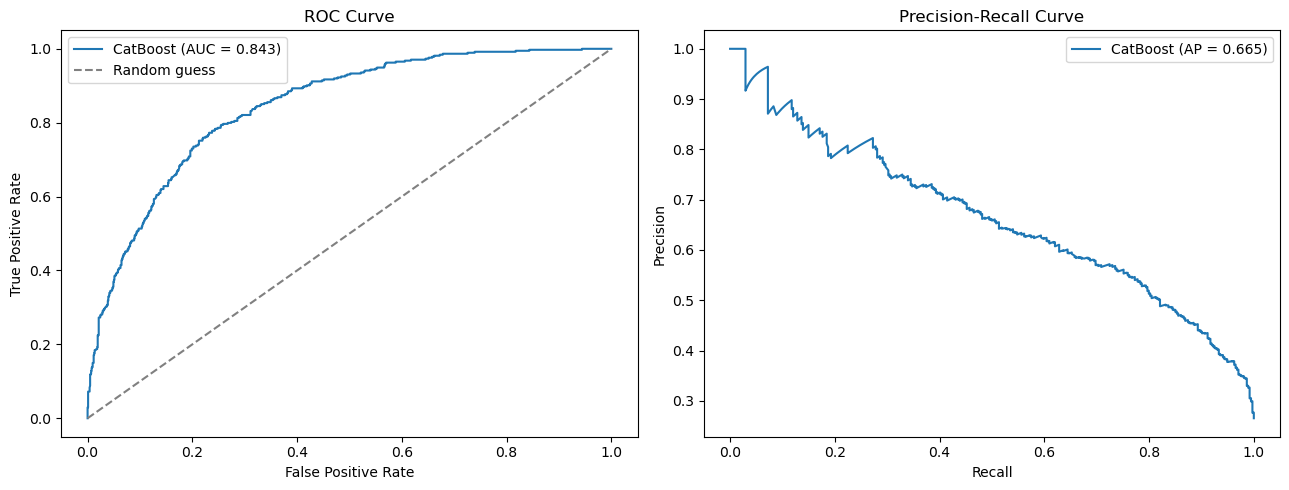

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curve
fpr, tpr, _ = roc_curve(y_test_encoded, y_test_proba)
auc_score = roc_auc_score(y_test_encoded, y_test_proba)
axes[0].plot(fpr, tpr, label=f'CatBoost (AUC = {auc_score:.3f})')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test_encoded, y_test_proba)
ap_score = average_precision_score(y_test_encoded, y_test_proba)
axes[1].plot(recall, precision, label=f'CatBoost (AP = {ap_score:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

### Threshold discussion (not yet decided)

`predict()` uses a default probability threshold of 0.5 to decide Churn vs. No Churn. That default isn't necessarily right for this business problem — since missing a churner (false negative) is usually costlier than a wasted retention offer (false positive), it may make sense to **lower** the threshold (e.g. to 0.35) to catch more churners at the cost of more false alarms.

**Not implemented yet** — this is a decision to make deliberately, informed by the PR curve above, before finalizing the model. Worth revisiting before Phase 14 (Model Saving).

## Phase 12: Explainable AI (SHAP)

`feature_importances_` only shows *which* features matter on average, globally. SHAP (SHapley Additive exPlanations) goes further:
- **Direction**: does a high value of a feature push predictions toward churn or away from it?
- **Per-customer explanations**: why did the model predict *this specific* customer will churn?
- **Global summary**: which features matter most overall, across the whole test set.

SHAP works natively with tree-based models like CatBoost via `TreeExplainer`, which computes exact Shapley values efficiently for tree ensembles (much faster than the general-purpose model-agnostic SHAP approach).

In [14]:
import shap

explainer = shap.TreeExplainer(final_model)

# CatBoost needs cat_features specified again here, same as training
test_pool = Pool(X_test, cat_features=cat_feature_indices)
shap_values = explainer.shap_values(test_pool)

print(f"SHAP values shape: {shap_values.shape}")  # (n_test_rows, n_features)

SHAP values shape: (1409, 17)


### Global feature importance (summary plot)

Each dot is one customer. Position on the x-axis shows how much that feature pushed *that customer's* prediction toward churn (right, positive) or away from it (left, negative). Color shows whether the feature's actual value was high (red) or low (blue) for that customer. Features are ranked top-to-bottom by overall importance.

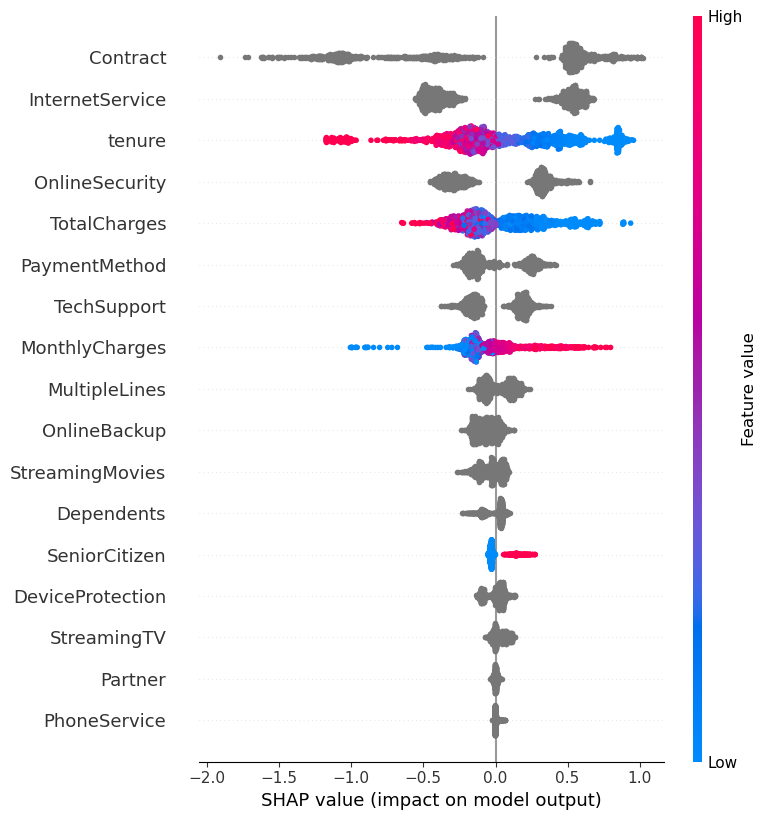

In [15]:
shap.summary_plot(shap_values, X_test, show=True)

### Global importance (bar chart version)

Same ranking as above, but collapsed to average absolute impact per feature — easier to read quickly, but loses the direction/spread information the dot plot shows.

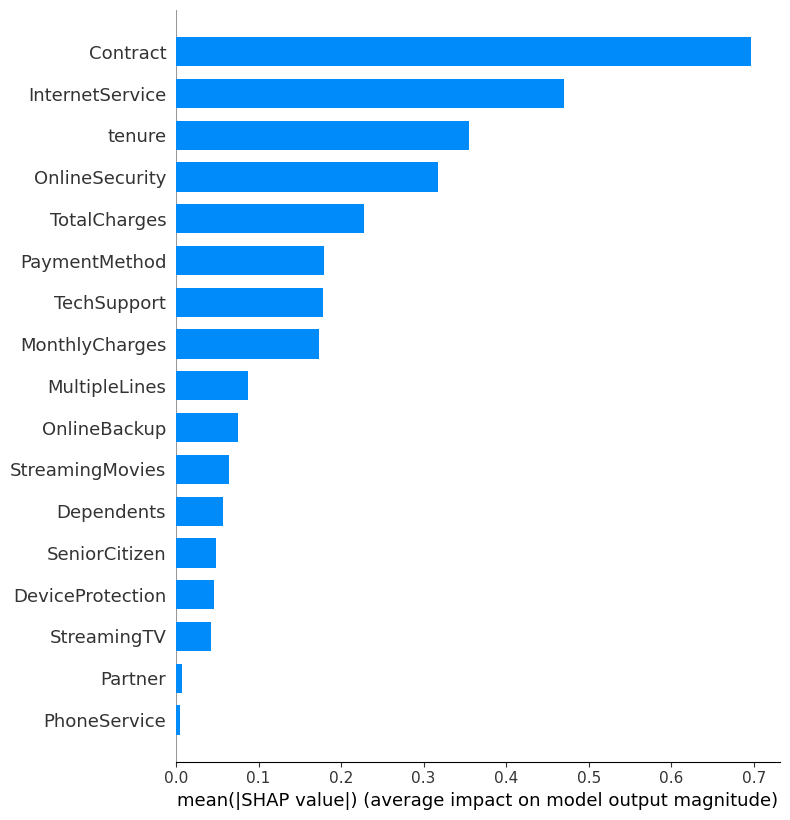

In [16]:
shap.summary_plot(shap_values, X_test, plot_type='bar', show=True)

### Local explanation: one individual prediction

Pick one customer from the test set and see exactly which features pushed their prediction up (toward churn, red) or down (toward no churn, blue). This is the kind of explanation you'd show a business stakeholder for a specific flagged customer, and it's also the foundation for Phase 13 (Error Analysis) — looking at *why* the model got specific predictions wrong.

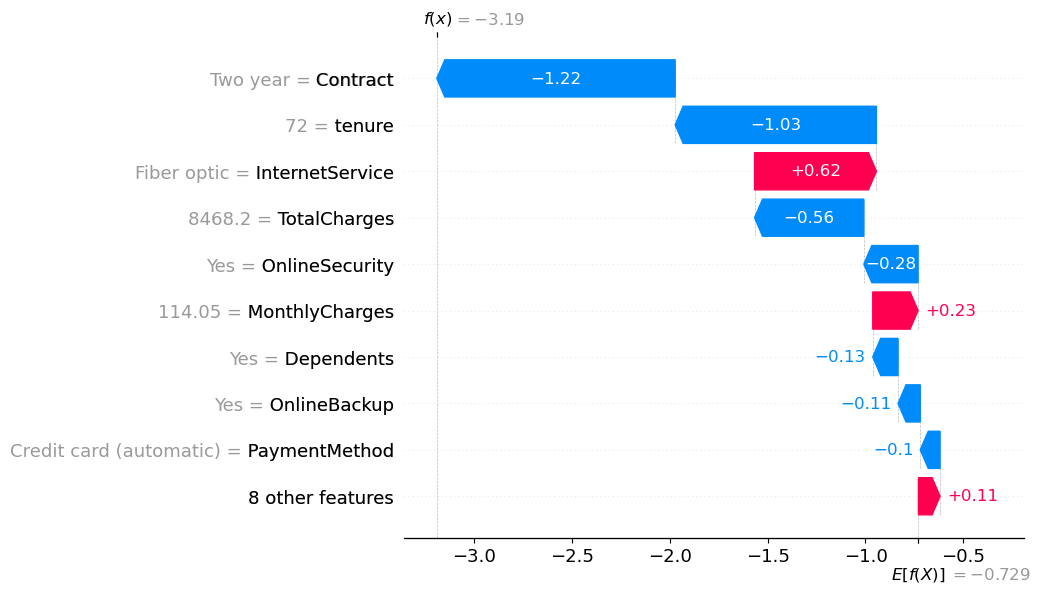

In [17]:
# Pick one customer to explain -- e.g. the first row of the test set.
# Swap this index to inspect different customers.
row_idx = 0

explanation = shap.Explanation(
    values=shap_values[row_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[row_idx],
    feature_names=X_test.columns.tolist()
)

shap.plots.waterfall(explanation, show=True)

In [18]:
# Identify misclassified customers
false_positives = X_test[(y_test_encoded == 0) & (y_test_pred == 1)]
false_negatives = X_test[(y_test_encoded == 1) & (y_test_pred == 0)]

print(f"False Positives (predicted churn, actually stayed): {len(false_positives)}")
print(f"False Negatives (predicted stay, actually churned): {len(false_negatives)}")

# Compare feature patterns: correctly predicted churners vs. missed churners (false negatives)
correct_churners = X_test[(y_test_encoded == 1) & (y_test_pred == 1)]

print("\n--- tenure ---")
print("Correctly caught churners  -> mean tenure:", correct_churners['tenure'].mean())
print("Missed churners (FN)       -> mean tenure:", false_negatives['tenure'].mean())

print("\n--- MonthlyCharges ---")
print("Correctly caught churners  -> mean:", correct_churners['MonthlyCharges'].mean())
print("Missed churners (FN)       -> mean:", false_negatives['MonthlyCharges'].mean())

print("\n--- Contract type distribution ---")
print("Correctly caught churners:\n", correct_churners['Contract'].value_counts(normalize=True))
print("\nMissed churners (FN):\n", false_negatives['Contract'].value_counts(normalize=True))

False Positives (predicted churn, actually stayed): 261
False Negatives (predicted stay, actually churned): 80

--- tenure ---
Correctly caught churners  -> mean tenure: 12.581632653061224
Missed churners (FN)       -> mean tenure: 30.725

--- MonthlyCharges ---
Correctly caught churners  -> mean: 74.91377551020408
Missed churners (FN)       -> mean: 64.878125

--- Contract type distribution ---
Correctly caught churners:
 Contract
Month-to-month    0.986395
One year          0.013605
Name: proportion, dtype: float64

Missed churners (FN):
 Contract
Month-to-month    0.4875
One year          0.4000
Two year          0.1125
Name: proportion, dtype: float64


In [20]:
import json
import os

os.makedirs("models", exist_ok=True)

final_model.save_model("models/catboost_churn_model.cbm")

metadata = {
    "categorical_columns": categorical_columns,
    "feature_names": X_train.columns.tolist(),
    "target_classes": le.classes_.tolist(),  # ['No', 'Yes'] -> confirms 0/1 mapping
}

with open("models/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Model and metadata saved successfully.")

Model and metadata saved successfully.


In [21]:
from catboost import CatBoostClassifier
import json

loaded_model = CatBoostClassifier()
loaded_model.load_model("models/catboost_churn_model.cbm")

with open("models/model_metadata.json") as f:
    metadata = json.load(f)